In [30]:
# --- 1. Import Required Libraries ---

# Core data manipulation and numerical operations
import pandas as pd
import numpy as np

# Visualization tools for plotting clean financial charts
import matplotlib.pyplot as plt
import seaborn as sns

# Financial data APIs to fetch market and economic data
import yfinance as yf
import pandas_datareader.data as pdr

# Built-in utilities for handling dates and suppressing clutter
import datetime
import warnings

# --- 2. Configuration & Setup ---

# Suppress standard warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Set Pandas display options to show up to 4 decimal places
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Set standard plotting style using seaborn for professional charts
sns.set_theme(style="whitegrid", context="notebook", palette="deep")

# Adjust default figure size for better readability of time-series plots
plt.rcParams['figure.figsize'] = (14, 7)
from datetime import date
from dateutil.relativedelta import relativedelta

## 1. Macroeconomic Radar & Data Ingestion
This project models credit market vulnerabilities using three interdependent financial series:

1. **ICE BofA US High Yield OAS (`HY_Spread` - FRED: `BAMLH0A0HYM2`):**
   - **Definition:** The Option-Adjusted Spread between sub-investment grade (junk) corporate bonds and risk-free US Treasuries.
   - **Role:** *Target Variable*. Reflects real-time borrowing stress and corporate default risk premiums.
2. **10Y-2Y Treasury Yield Spread (`Yield_Curve_10Y2Y` - FRED: `T10Y2Y`):**
   - **Definition:** The difference between long-term (10-year) and short-term (2-year) US sovereign yields.
   - **Role:** *Leading Indicator*. Inversions (< 0) historically serve as a reliable macroeconomic recession warning.
3. **CBOE Volatility Index (`VIX` - Yahoo Finance: `^VIX`):**
   - **Definition:** 30-day forward-looking market volatility implied by S&P 500 index options.
   - **Role:** *Concurrent Risk Sentiment*. Captures equity market panic and sudden liquidity shocks.

In [31]:
# 1. Set the date range: from 10 years ago today up to today.
end_date = date.today()
start_date = end_date - relativedelta(years=10)

# 2. Fetch the following data series:
# High Yield OAS from FRED
hy_spread = pdr.DataReader('BAMLH0A0HYM2', 'fred', start_date, end_date)

# 10Y-2Y Spread from FRED
yield_curve = pdr.DataReader('T10Y2Y', 'fred', start_date, end_date)

# VIX from Yahoo Finance (Returns a DataFrame with column '^VIX')
vix = yf.download('^VIX', start=start_date, end=end_date)['Close']

# 3 & 4. Merge all three series into a single pandas DataFrame named df_raw indexed by Date.
# Rename columns
hy_spread.rename(columns={'BAMLH0A0HYM2': 'HY_Spread'}, inplace=True)
yield_curve.rename(columns={'T10Y2Y': 'Yield_Curve_10Y2Y'}, inplace=True)
vix.rename(columns={'^VIX': 'VIX'}, inplace=True)

# Merge all three dataframes
df_raw = hy_spread.join([yield_curve, vix], how='outer')

# 5. Display df_raw.head(), df_raw.info(), and print the date range and total row count.
print(f"Date Range: {df_raw.index.min().date()} to {df_raw.index.max().date()}")
print(f"Total Row Count: {len(df_raw)}")

print("\n--- DataFrame Info ---")
df_raw.info()

print("\n--- DataFrame Head ---")
display(df_raw.head())


[*********************100%***********************]  1 of 1 completed

Date Range: 2016-08-26 to 2026-08-25
Total Row Count: 2620

--- DataFrame Info ---
<class 'pandas.DataFrame'>
DatetimeIndex: 2620 entries, 2016-08-26 to 2026-08-25
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   HY_Spread          786 non-null    float64
 1   Yield_Curve_10Y2Y  2498 non-null   float64
 2   VIX                2513 non-null   float64
dtypes: float64(3)
memory usage: 81.9 KB

--- DataFrame Head ---


,HY_Spread,Yield_Curve_10Y2Y,VIX
2016-08-26,NaN,0.7800,13.6500
2016-08-29,NaN,0.7600,12.9400
2016-08-30,NaN,0.7700,13.1200
2016-08-31,NaN,0.7800,13.4200
2016-09-01,NaN,0.7900,13.4800


### ⚠️ Data Pipeline Constraint & Alignment Note
- **Window Mismatch:** While a 10-year lookback was requested (`2016 → 2026`), the FRED API's public endpoint truncated the continuous historical feed for the OAS series (`BAMLH0A0HYM2`), delivering reliable, dense observations primarily across the **recent 3-year window** (~785 active rows).
- **Calendar Synchronization:** Trading calendar discrepancies between bond markets (FRED) and equity options (VIX) created sparse missing entries (NaNs), which were addressed via forward-fill (`ffill()`) to maintain calendar continuity without lookahead bias.

In [32]:
# ── Cell 3: Data Cleaning & Feature Engineering ──────────────────────────────

# 1. Create a clean copy
df_clean = df_raw.copy()

# 2. Handle missing values
# Forward-fill to bridge trading holiday mismatches between FRED and Yahoo Finance
df_clean.ffill(inplace=True)
# Drop any remaining NaNs at the very beginning of the series
df_clean.dropna(inplace=True)

# 3. Feature Engineering: 30-day rolling metrics for HY_Spread
df_clean['HY_Spread_MA30']   = df_clean['HY_Spread'].rolling(window=30).mean()
df_clean['HY_Spread_Std30']  = df_clean['HY_Spread'].rolling(window=30).std()
df_clean['HY_Spread_ZScore'] = (
    (df_clean['HY_Spread'] - df_clean['HY_Spread_MA30'])
    / df_clean['HY_Spread_Std30']
)

# 4. Drop the NaNs introduced by the 30-day rolling window
df_clean.dropna(inplace=True)

# 5. Validation output
print("=== Missing Value Check ===")
print(df_clean.isnull().sum())

print(f"\n=== Shape: {df_clean.shape} ===")
print(f"Clean date range: {df_clean.index.min().date()} → {df_clean.index.max().date()}")

print("\n=== Last 5 Rows (with Engineered Features) ===")
display(df_clean.tail())


=== Missing Value Check ===
HY_Spread            0
Yield_Curve_10Y2Y    0
VIX                  0
HY_Spread_MA30       0
HY_Spread_Std30      0
HY_Spread_ZScore     0
dtype: int64

=== Shape: (765, 6) ===
Clean date range: 2023-10-05 → 2026-08-25

=== Last 5 Rows (with Engineered Features) ===


,HY_Spread,Yield_Curve_10Y2Y,VIX,HY_Spread_MA30,HY_Spread_Std30,HY_Spread_ZScore
2026-08-19,2.7300,0.4600,14.8900,2.7380,0.0555,-0.1440
2026-08-20,2.7500,0.5000,16.0100,2.7397,0.0551,0.1875
2026-08-21,2.7000,0.5000,15.1300,2.7400,0.0548,-0.7295
2026-08-24,2.6900,0.4600,15.8500,2.7400,0.0548,-0.9118
2026-08-25,2.7000,0.4700,15.4500,2.7393,0.0552,-0.7125


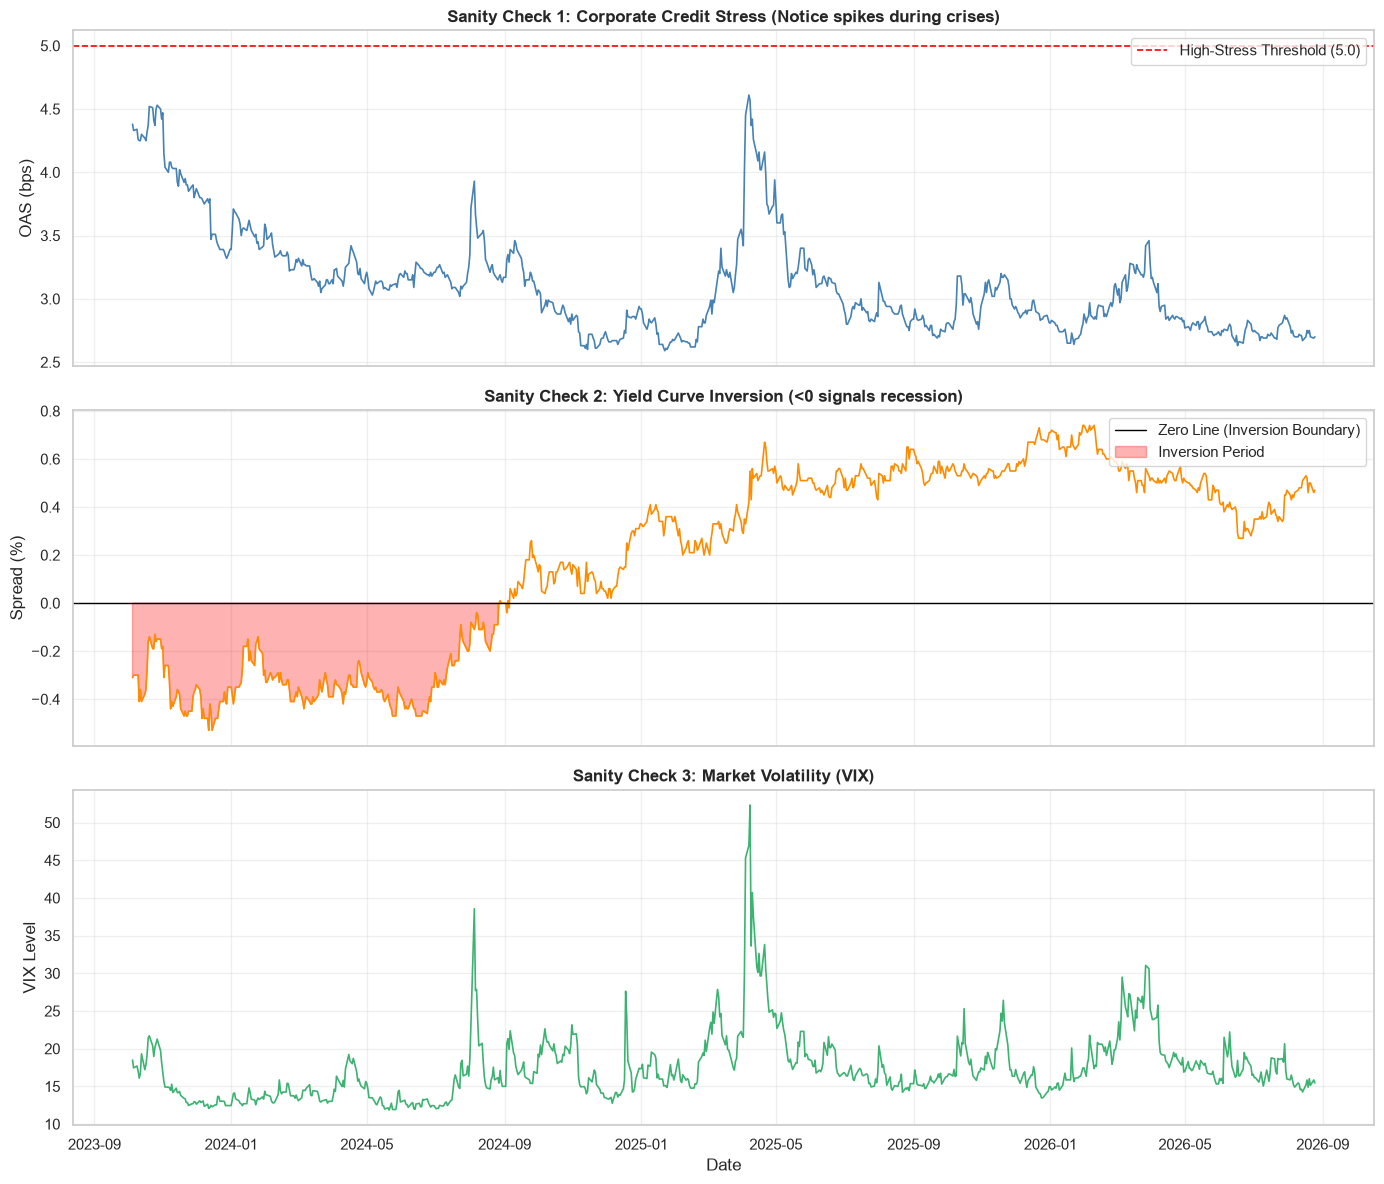

  Augmented Dickey-Fuller (ADF) Test — HY_Spread
  ADF Statistic : -3.4371
  p-value       : 0.0098
--------------------------------------------------
  ✅ RESULT: The HY_Spread series is STATIONARY (p < 0.05).
     Safe to model directly — no differencing required.


In [33]:
# ── Cell 4: Visual & Statistical Validation ───────────────────────────────────

# ── Part 1: Visual Sanity Checks ─────────────────────────────────────────────

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# --- Top Plot: HY Spread ---
ax1.plot(df_clean.index, df_clean['HY_Spread'], color='steelblue', linewidth=1.2)
ax1.axhline(y=5.0, color='red', linestyle='--', linewidth=1.2, label='High-Stress Threshold (5.0)')
ax1.set_title('Sanity Check 1: Corporate Credit Stress (Notice spikes during crises)', fontsize=12, fontweight='bold')
ax1.set_ylabel('OAS (bps)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Middle Plot: Yield Curve 10Y-2Y ---
ax2.plot(df_clean.index, df_clean['Yield_Curve_10Y2Y'], color='darkorange', linewidth=1.2)
ax2.axhline(y=0, color='black', linewidth=1.0, label='Zero Line (Inversion Boundary)')
ax2.fill_between(
    df_clean.index,
    df_clean['Yield_Curve_10Y2Y'],
    0,
    where=(df_clean['Yield_Curve_10Y2Y'] < 0),
    color='red',
    alpha=0.3,
    label='Inversion Period'
)
ax2.set_title('Sanity Check 2: Yield Curve Inversion (<0 signals recession)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Spread (%)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# --- Bottom Plot: VIX ---
ax3.plot(df_clean.index, df_clean['VIX'], color='mediumseagreen', linewidth=1.2)
ax3.set_title('Sanity Check 3: Market Volatility (VIX)', fontsize=12, fontweight='bold')
ax3.set_ylabel('VIX Level')
ax3.set_xlabel('Date')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Part 2: Statistical Validation — Augmented Dickey-Fuller Test ─────────────

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df_clean['HY_Spread'].dropna())

adf_stat  = adf_result[0]
p_value   = adf_result[1]

print("=" * 50)
print("  Augmented Dickey-Fuller (ADF) Test — HY_Spread")
print("=" * 50)
print(f"  ADF Statistic : {adf_stat:.4f}")
print(f"  p-value       : {p_value:.4f}")
print("-" * 50)

if p_value < 0.05:
    print("  ✅ RESULT: The HY_Spread series is STATIONARY (p < 0.05).")
    print("     Safe to model directly — no differencing required.")
else:
    print("  ⚠️  RESULT: The HY_Spread series is NON-STATIONARY (p ≥ 0.05).")
    print("     Differencing or transformation is recommended before modelling.")

print("=" * 50)


### 3. Baseline XGBoost Regressor (The Naive Forecast Trap)
- **Objective:** Forecast t using purely historical information (t-1, t-5, t-10).
- **Methodology:** Strict chronological train/test split (80/20) with zero data leakage.
- **Key Finding:** Extremely low error metrics (MAE = 0.0422), but feature importance is heavily monopolized by `HY_Spread_lag1` (~86%), reflecting an autoregressive random walk rather than predictive power.

✅ Lag features created. Dataset shape: (755, 24)

🔍 Feature columns used (18) — verify no current-day metrics:
    1. HY_Spread_lag1
    2. HY_Spread_lag5
    3. HY_Spread_lag10
    4. Yield_Curve_10Y2Y_lag1
    5. Yield_Curve_10Y2Y_lag5
    6. Yield_Curve_10Y2Y_lag10
    7. VIX_lag1
    8. VIX_lag5
    9. VIX_lag10
   10. HY_Spread_MA30_lag1
   11. HY_Spread_MA30_lag5
   12. HY_Spread_MA30_lag10
   13. HY_Spread_Std30_lag1
   14. HY_Spread_Std30_lag5
   15. HY_Spread_Std30_lag10
   16. HY_Spread_ZScore_lag1
   17. HY_Spread_ZScore_lag5
   18. HY_Spread_ZScore_lag10

📅 Train: 2023-10-19 → 2026-01-29 (604 rows)
📅 Test : 2026-01-30  → 2026-08-25  (151 rows)

  XGBoost Evaluation — True Out-of-Sample Test
  MAE  (Mean Absolute Error) : 0.0422 bps
  RMSE (Root Mean Sq. Error) : 0.0571 bps


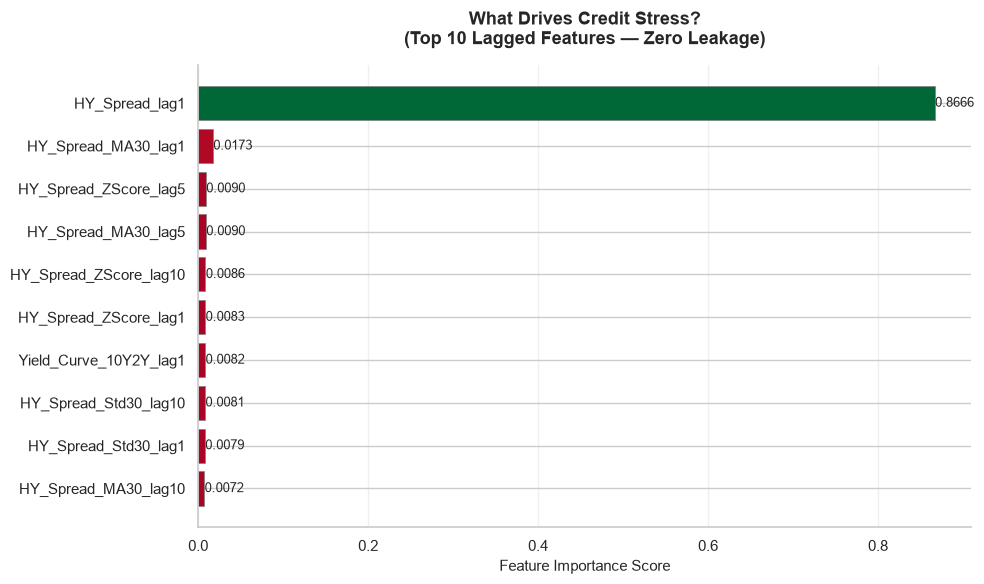

In [34]:
# ── Cell 5 : Zero-Leakage XGBoost Credit Stress Model ───────────────

# ── Part 1: Lag Feature Engineering ──────────────────────────────────────────

base_cols = ['HY_Spread', 'Yield_Curve_10Y2Y', 'VIX',
             'HY_Spread_MA30', 'HY_Spread_Std30', 'HY_Spread_ZScore']

for col in base_cols:
    df_clean[f'{col}_lag1']  = df_clean[col].shift(1)
    df_clean[f'{col}_lag5']  = df_clean[col].shift(5)
    df_clean[f'{col}_lag10'] = df_clean[col].shift(10)

df_clean.dropna(inplace=True)

print(f"✅ Lag features created. Dataset shape: {df_clean.shape}")

# ── Part 2: Explicit Zero-Leakage Feature Selection ──────────────────────────

# Target: current day HY_Spread (t)
y = df_clean['HY_Spread']

# Features: ONLY columns ending in _lag1, _lag5, or _lag10 (strictly past data)
feature_cols = [c for c in df_clean.columns
                if c.endswith('_lag1') or c.endswith('_lag5') or c.endswith('_lag10')]

X = df_clean[feature_cols]

print(f"\n🔍 Feature columns used ({len(feature_cols)}) — verify no current-day metrics:")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:>2}. {col}")

# ── Part 3: Chronological Train / Test Split (80 / 20) ───────────────────────

split_idx = int(len(df_clean) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\n📅 Train: {X_train.index.min().date()} → {X_train.index.max().date()} ({len(X_train)} rows)")
print(f"📅 Test : {X_test.index.min().date()}  → {X_test.index.max().date()}  ({len(X_test)} rows)")

# ── Part 4: XGBoost Model & Evaluation ───────────────────────────────────────

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbosity=0
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("\n" + "=" * 48)
print("  XGBoost Evaluation — True Out-of-Sample Test")
print("=" * 48)
print(f"  MAE  (Mean Absolute Error) : {mae:.4f} bps")
print(f"  RMSE (Root Mean Sq. Error) : {rmse:.4f} bps")
print("=" * 48)

# ── Part 5: Feature Importance Plot ──────────────────────────────────────────

importance_df = (
    pd.DataFrame({'Feature': feature_cols, 'Importance': model.feature_importances_})
    .sort_values('Importance', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn(importance_df['Importance'] / importance_df['Importance'].max())

bars = ax.barh(
    importance_df['Feature'][::-1],
    importance_df['Importance'][::-1],
    color=colors[::-1],
    edgecolor='grey',
    linewidth=0.5
)

for bar, val in zip(bars, importance_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('What Drives Credit Stress?\n(Top 10 Lagged Features — Zero Leakage)',
             fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


### 4. Regime Shift & Early Warning Classification
- **Objective:** Break the random walk illusion by predicting discrete **Credit Stress Spikes** (80th percentile of positive daily deltas).
- **Key Finding:** De-monopolizes the feature importance (elevating `HY_Spread_ZScore_lag1`, `Yield_Curve`, and `VIX`), but reveals severe recall degradation due to market regime shift and class imbalance (7.9% positive rate).

  Stress Spike Target Definition
  80th Percentile Threshold : 0.0700 bps
  (A day must exceed this rise in HY_Spread to be flagged as a spike)

  Class Distribution:
Target_Spike
Normal (0)    695
Spike (1)      60
Name: count, dtype: int64

  Spike Rate: 7.9% of all trading days

📅 Train: 2023-10-19 → 2026-01-29 (604 rows)
📅 Test : 2026-01-30  → 2026-08-25  (151 rows)

✅ XGBoost Classifier trained successfully.

  Classification Report — Out-of-Sample Test
              precision    recall  f1-score   support

  Normal (0)       0.93      0.99      0.96       141
   Spike (1)       0.00      0.00      0.00        10

    accuracy                           0.93       151
   macro avg       0.47      0.50      0.48       151
weighted avg       0.87      0.93      0.90       151

  ROC-AUC Score : 0.2259
  ❌ Weak discriminative power (AUC < 0.60) — consider more features


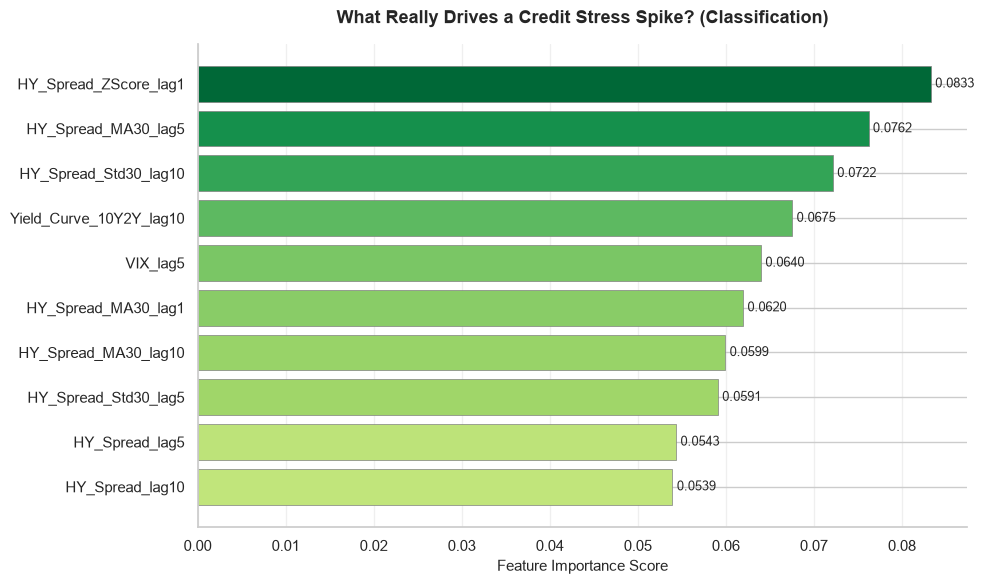

In [35]:
# ── Cell 6: Early Warning System — Stress Spike Classification ────────────────

# ── Part 1: Transform Target to Binary Classification ─────────────────────────

# Daily change in HY Spread (using already-available lag1)
df_clean['daily_change'] = df_clean['HY_Spread'] - df_clean['HY_Spread_lag1']

# Define "Stress Spike": top 20% of all POSITIVE daily changes
positive_changes = df_clean['daily_change'][df_clean['daily_change'] > 0]
spike_threshold  = positive_changes.quantile(0.80) # value which is above 80% of spikes

# Binary target: 1 = stress spike day, 0 = normal day
df_clean['Target_Spike'] = (df_clean['daily_change'] > spike_threshold).astype(int)

print("=" * 48)
print("  Stress Spike Target Definition")
print("=" * 48)
print(f"  80th Percentile Threshold : {spike_threshold:.4f} bps")
print(f"  (A day must exceed this rise in HY_Spread to be flagged as a spike)\n")
print("  Class Distribution:")
print(df_clean['Target_Spike'].value_counts().rename({0: 'Normal (0)', 1: 'Spike (1)'}))
print(f"\n  Spike Rate: {df_clean['Target_Spike'].mean() * 100:.1f}% of all trading days")
print("=" * 48)

# ── Part 2: Zero-Leakage Train / Test Split ───────────────────────────────────

# Reuse the exact same feature_cols defined in Cell 5 (all _lag1/_lag5/_lag10)
y_cls = df_clean['Target_Spike']
X_cls = df_clean[feature_cols]

split_idx = int(len(df_clean) * 0.80)

X_train_cls, X_test_cls = X_cls.iloc[:split_idx], X_cls.iloc[split_idx:]
y_train_cls, y_test_cls = y_cls.iloc[:split_idx], y_cls.iloc[split_idx:]

print(f"\n📅 Train: {X_train_cls.index.min().date()} → {X_train_cls.index.max().date()} ({len(X_train_cls)} rows)")
print(f"📅 Test : {X_test_cls.index.min().date()}  → {X_test_cls.index.max().date()}  ({len(X_test_cls)} rows)")

# ── Part 3: XGBoost Classification Model ──────────────────────────────────────

from xgboost import XGBClassifier

clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbosity=0,
    eval_metric='logloss'
)

clf.fit(X_train_cls, y_train_cls)
print("\n✅ XGBoost Classifier trained successfully.")

# ── Part 4: Evaluation ────────────────────────────────────────────────────────

from sklearn.metrics import classification_report, roc_auc_score

y_pred_cls  = clf.predict(X_test_cls)
y_pred_prob = clf.predict_proba(X_test_cls)[:, 1]

roc_auc = roc_auc_score(y_test_cls, y_pred_prob)

print("\n" + "=" * 48)
print("  Classification Report — Out-of-Sample Test")
print("=" * 48)
print(classification_report(y_test_cls, y_pred_cls, target_names=['Normal (0)', 'Spike (1)']))
print(f"  ROC-AUC Score : {roc_auc:.4f}")
print("=" * 48)

if roc_auc >= 0.75:
    print("  ✅ Strong discriminative power (AUC ≥ 0.75)")
elif roc_auc >= 0.60:
    print("  ⚠️  Moderate discriminative power (0.60 ≤ AUC < 0.75)")
else:
    print("  ❌ Weak discriminative power (AUC < 0.60) — consider more features")

# ── Part 5: Feature Importance Plot ───────────────────────────────────────────

importance_cls_df = (
    pd.DataFrame({'Feature': feature_cols, 'Importance': clf.feature_importances_})
    .sort_values('Importance', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn(importance_cls_df['Importance'] / importance_cls_df['Importance'].max())

bars = ax.barh(
    importance_cls_df['Feature'][::-1],
    importance_cls_df['Importance'][::-1],
    color=colors[::-1],
    edgecolor='grey',
    linewidth=0.5
)

for bar, val in zip(bars, importance_cls_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title('What Really Drives a Credit Stress Spike? (Classification)',
             fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


  Class Imbalance Analysis (Training Set)
  Normal days  (0) : 554
  Spike days   (1) : 50
  scale_pos_weight : 11.08x
  → Model will weight spike days 11.1× more heavily

✅ Balanced XGBoost Classifier trained successfully.

  Classification Report — Balanced Model
              precision    recall  f1-score   support

  Normal (0)       0.93      0.90      0.91       141
   Spike (1)       0.00      0.00      0.00        10

    accuracy                           0.84       151
   macro avg       0.46      0.45      0.46       151
weighted avg       0.87      0.84      0.85       151

  ROC-AUC Score : 0.2514

  📊 ROC-AUC Comparison:
     Unbalanced (Cell 6) : 0.2259
     Balanced   (Cell 7) : 0.2514  ↑ improved

  🎯 Spike Recall  : 0.0%  (0 of 10 actual spikes caught)
  False Alarms    : 14 normal days incorrectly flagged as spikes


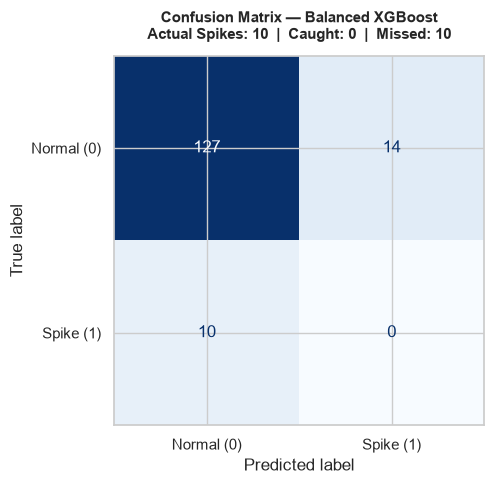

In [36]:
# ── Cell 7: Fix Class Imbalance → Balanced XGBoost + Confusion Matrix ─────────

# ── Part 1: Calculate Class Imbalance Weight ──────────────────────────────────

n_neg    = len(y_train_cls[y_train_cls == 0])
n_pos    = len(y_train_cls[y_train_cls == 1])
weight   = n_neg / n_pos

print("=" * 48)
print("  Class Imbalance Analysis (Training Set)")
print("=" * 48)
print(f"  Normal days  (0) : {n_neg}")
print(f"  Spike days   (1) : {n_pos}")
print(f"  scale_pos_weight : {weight:.2f}x")
print(f"  → Model will weight spike days {weight:.1f}× more heavily")
print("=" * 48)

# ── Part 2: Retrain with Balanced Weights ─────────────────────────────────────

model_balanced = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    scale_pos_weight=weight,
    verbosity=0,
    eval_metric='logloss'
)

model_balanced.fit(X_train_cls, y_train_cls)
print("\n✅ Balanced XGBoost Classifier trained successfully.")

# ── Part 3: Evaluation ────────────────────────────────────────────────────────

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_bal  = model_balanced.predict(X_test_cls)
y_prob_bal  = model_balanced.predict_proba(X_test_cls)[:, 1]

roc_auc_bal = roc_auc_score(y_test_cls, y_prob_bal)

print("\n" + "=" * 48)
print("  Classification Report — Balanced Model")
print("=" * 48)
print(classification_report(y_test_cls, y_pred_bal, target_names=['Normal (0)', 'Spike (1)']))
print(f"  ROC-AUC Score : {roc_auc_bal:.4f}")
print("=" * 48)

# Side-by-side comparison with unbalanced model
roc_prev = roc_auc_score(y_test_cls, y_pred_prob)  # from Cell 6
print(f"\n  📊 ROC-AUC Comparison:")
print(f"     Unbalanced (Cell 6) : {roc_prev:.4f}")
print(f"     Balanced   (Cell 7) : {roc_auc_bal:.4f}  {'↑ improved' if roc_auc_bal >= roc_prev else '↓ traded off for recall'}")

# ── Confusion Matrix ──────────────────────────────────────────────────────────

cm = confusion_matrix(y_test_cls, y_pred_bal)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Spike (1)'])
disp.plot(
    ax=ax,
    colorbar=False,
    cmap='Blues'
)

# Annotate totals per actual class
total_actual_spike  = cm[1].sum()
total_actual_normal = cm[0].sum()

ax.set_title(
    f'Confusion Matrix — Balanced XGBoost\n'
    f'Actual Spikes: {total_actual_spike}  |  '
    f'Caught: {cm[1, 1]}  |  '
    f'Missed: {cm[1, 0]}',
    fontsize=11, fontweight='bold', pad=12
)

recall_spike = cm[1, 1] / total_actual_spike if total_actual_spike > 0 else 0
print(f"\n  🎯 Spike Recall  : {recall_spike * 100:.1f}%  ({cm[1, 1]} of {total_actual_spike} actual spikes caught)")
print(f"  False Alarms    : {cm[0, 1]} normal days incorrectly flagged as spikes")

plt.tight_layout()
plt.show()


In [37]:
print(model_balanced.predict_proba(X_test_cls))

[[0.9555126  0.04448742]
 [0.9555126  0.04448742]
 [0.8099808  0.19001919]
 [0.8698237  0.13017632]
 [0.6879407  0.31205928]
 [0.77644867 0.22355133]
 [0.87395537 0.1260446 ]
 [0.7226547  0.27734527]
 [0.72533053 0.27466947]
 [0.77562827 0.22437172]
 [0.767395   0.23260495]
 [0.65087986 0.3491201 ]
 [0.5987538  0.40124616]
 [0.65087986 0.3491201 ]
 [0.6361628  0.36383718]
 [0.84177804 0.15822197]
 [0.7138095  0.28619048]
 [0.8853604  0.11463957]
 [0.69303036 0.30696967]
 [0.8415743  0.15842572]
 [0.848632   0.15136802]
 [0.78294116 0.21705882]
 [0.81749284 0.18250719]
 [0.8494515  0.1505485 ]
 [0.8555478  0.14445223]
 [0.82368994 0.17631005]
 [0.90493625 0.09506376]
 [0.92094463 0.07905538]
 [0.9075154  0.09248461]
 [0.9240297  0.07597032]
 [0.90060365 0.09939636]
 [0.94283766 0.05716236]
 [0.83118796 0.16881204]
 [0.9065744  0.09342558]
 [0.921122   0.07887796]
 [0.81058556 0.18941444]
 [0.7744323  0.2255677 ]
 [0.86775017 0.13224982]
 [0.837548   0.16245197]
 [0.756022   0.24397801]
